h = 0.01 : unstable
h = 0.05 : unstable
h = 0.15 : unstable
h = 0.2 : unstable
h = 0.25 : unstable
h = 0.5 : unstable
h = 1.0 : unstable
h = 1.2 : unstable


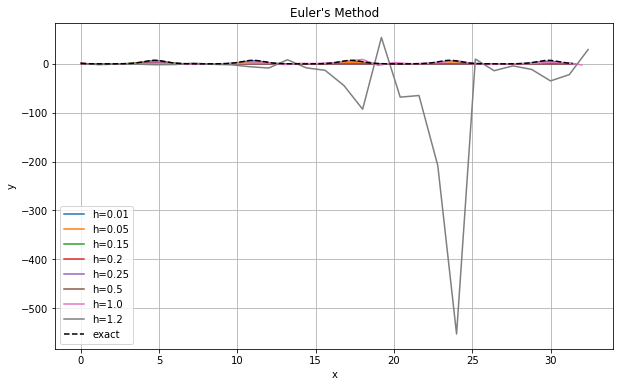

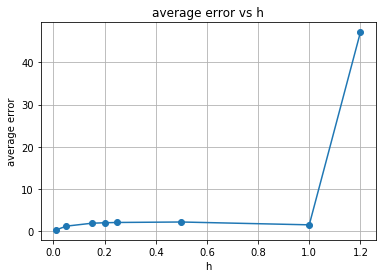

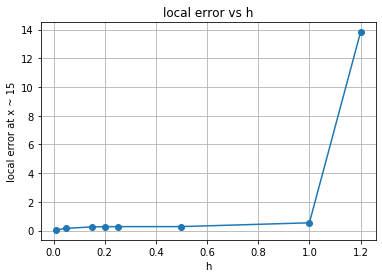

In [4]:
import numpy as np
import matplotlib.pyplot as plt
def f(x, y):
    return -2 * y * np.cos(x)
def y_exact(x):
    return np.exp(-2 * np.sin(x))
h_list = [0.01, 0.05, 0.15, 0.2, 0.25, 0.5, 1.0, 1.2]
x0 = 0
xf = 10 * np.pi
y0 = 1.0
avg_errors = []
local_errors = []
plt.figure(figsize=(10,6))

for h in h_list:
    x = np.arange(x0, xf + h, h)
    y = np.zeros(len(x))
    y[0] = y0
    for i in range(len(x) - 1):
        y[i+1] = y[i] + h * f(x[i], y[i])
    y_true = y_exact(x)
    plt.plot(x, y, label="h=" + str(h))
    err = np.abs(y - y_true)
    avg_errors.append(np.mean(err))
    idx = np.argmin(np.abs(x - 15))
    local_errors.append(abs(y[idx] - y_true[idx]))
    
    lam = -2 * np.cos(x)
    g = 1 + h * lam
    if np.all(np.abs(g) < 1):
        print("h =", h, ": stable")
    elif np.any(np.abs(g) > 1):
        print("h =", h, ": unstable")
    else:
        print("h =", h, ": borderline")
        
x_exact = np.linspace(x0, xf, 2000)
plt.plot(x_exact, y_exact(x_exact), 'k--', label="exact")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler's Method")
plt.legend()
plt.grid()
plt.show()

# average error vs h
plt.figure()
plt.plot(h_list, avg_errors, 'o-')
plt.xlabel("h")
plt.ylabel("average error")
plt.title("average error vs h")
plt.grid()
plt.show()

# local error vs h
plt.figure()
plt.plot(h_list, local_errors, 'o-')
plt.xlabel("h")
plt.ylabel("local error at x ~ 15")
plt.title("local error vs h")
plt.grid()
plt.show()

The true solution is bounded, however, this does not guarantee numerical stability. Again, as step size increases, the Euler method can cause for oscillations to step out of these bounds. 

#### OpenAI. (2026). ChatGPT (GPT-5.3) Prompted ChatGPT to assist with interpretation of graphs and code. Also prompted it to assist with plotting. 